In [7]:
"""Import the model"""
import os
os.environ["TF_USE_LEGACY_KERAS"] = "True"
from adtof.model.model import Model

model, hparams = Model.modelFactory(modelName="Frame_RNN", scenario="adtofAll", fold=0)
assert "peakThreshold" in hparams
assert model.weightLoadedFlag

In [8]:
"""Transcribe any audio file."""

# Change the paths according to your configuration
audioFiles = r"C:\Users\rsanc\Documents\Proyectos\ADTOF-master\audio files\Borivers - Stadium Rock Drum Fill_05 - 111 BPM.wav"
outputLocation = r"C:\Users\rsanc\Documents\Proyectos\ADTOF-master\audio output"
model.predictFolder(audioFiles, outputLocation, **hparams)


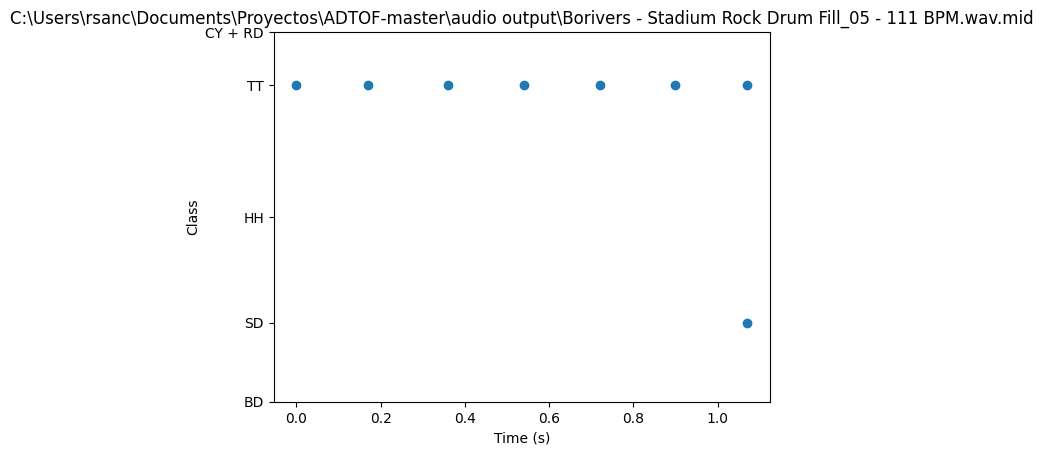

In [9]:
"""plot the estimated transcription"""
import pretty_midi
import glob
import matplotlib.pyplot as plt

for file in glob.glob(outputLocation+"/*.mid"):
    transcription = pretty_midi.PrettyMIDI(file)
    plt.scatter([note.start for note in transcription.instruments[0].notes], [note.pitch for note in transcription.instruments[0].notes])
    plt.yticks([35, 38, 42, 47, 49], ["BD", "SD", "HH", "TT", "CY + RD"])
    plt.title(file)
    plt.xlabel("Time (s)")
    plt.ylabel("Class")
    plt.show()
    break